In [1]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

In [2]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.7.1+cu118
CUDA available: True
Device: NVIDIA GeForce RTX 3050 6GB Laptop GPU



0: 640x480 4 persons, 1 bus, 130.2ms
Speed: 6.7ms preprocess, 130.2ms inference, 89.7ms postprocess per image at shape (1, 3, 640, 480)


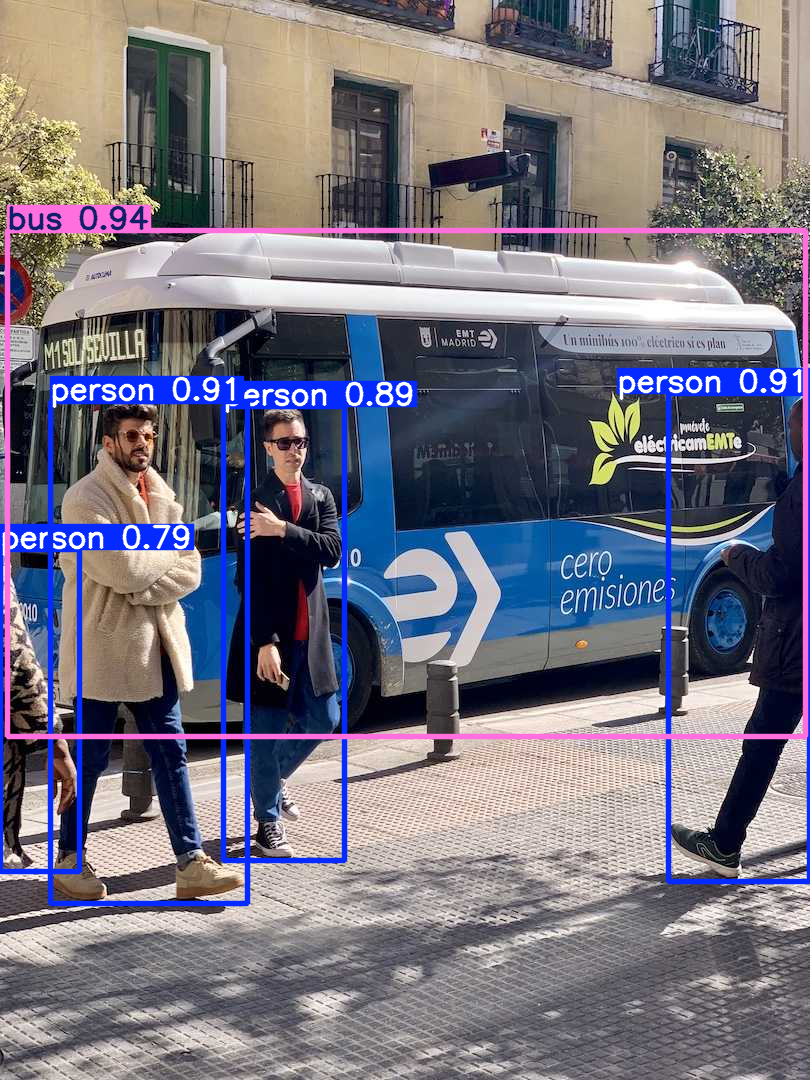

In [1]:
from ultralytics import YOLO

# Load a model
model = YOLO("yolo11x.pt")  # pretrained YOLO11n model

# Run batched inference on a list of images
results = model(["https://ultralytics.com/images/bus.jpg"])  # return a list of Results objects

# Process results list
for result in results:
    boxes = result.boxes  # Boxes object for bounding box outputs
    masks = result.masks  # Masks object for segmentation masks outputs
    keypoints = result.keypoints  # Keypoints object for pose outputs
    probs = result.probs  # Probs object for classification outputs
    obb = result.obb  # Oriented boxes object for OBB outputs
    result.show()  # display to screen

In [33]:
for result in results:
    boxes = result.boxes  # Boxes object for bounding box outputs
    #masks = result.masks  # Masks object for segmentation masks outputs
    #keypoints = result.keypoints  # Keypoints object for pose outputs
    #probs = result.probs  # Probs object for classification outputs
    #obb = result.obb  # Oriented boxes object for OBB outputs
    print(boxes.xyxy)
    print(probs)

tensor([[7.1891e+00, 2.3097e+02, 8.0511e+02, 7.3684e+02],
        [5.0006e+01, 4.0153e+02, 2.4736e+02, 9.0375e+02],
        [6.6845e+02, 3.9344e+02, 8.0946e+02, 8.8185e+02],
        [2.2367e+02, 4.0623e+02, 3.4467e+02, 8.6034e+02],
        [1.7446e-01, 5.4995e+02, 7.9012e+01, 8.7194e+02]], device='cuda:0')
None


In [61]:
print(results[0].boxes.xyxy)
#print(results[0].cls)
#print(results[0].names)
print(results[0].boxes.conf)
print(results[0].boxes.cls)
# Convert class indices to names
cls_indices = results[0].boxes.cls.int().cpu().tolist()
class_names = [results[0].names[i] for i in cls_indices]
print(class_names)

tensor([[7.1891e+00, 2.3097e+02, 8.0511e+02, 7.3684e+02],
        [5.0006e+01, 4.0153e+02, 2.4736e+02, 9.0375e+02],
        [6.6845e+02, 3.9344e+02, 8.0946e+02, 8.8185e+02],
        [2.2367e+02, 4.0623e+02, 3.4467e+02, 8.6034e+02],
        [1.7446e-01, 5.4995e+02, 7.9012e+01, 8.7194e+02]], device='cuda:0')
tensor([0.9350, 0.9147, 0.9126, 0.8934, 0.7900], device='cuda:0')
tensor([5., 0., 0., 0., 0.], device='cuda:0')
['bus', 'person', 'person', 'person', 'person']


In [3]:
boxes = results[0].boxes.xyxy.int().cpu().tolist()
cls_indices = result.boxes.cls.int().cpu().tolist()
class_names = [result.names[i] for i in cls_indices]
scores = result.boxes.conf.cpu().tolist()

NameError: name 'results' is not defined

In [4]:
print(scores)

NameError: name 'scores' is not defined

In [2]:
print(scores>0.5)

NameError: name 'scores' is not defined

In [1]:
import shutil
# Zipping a folder
shutil.make_archive('file', 'zip', 'file')


'/workspace/sam2/server/file.zip'